pip install numpy pandas matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"Dataset\train.csv")
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
251206,251206,365262,365263,Who would win in a fight between Tyrion Lannis...,How do cartographers detect trails that are no...,0
123032,123032,199011,144560,What services are provided by dailychanges.com?,What is the service provided by acocio.com?,0
68565,68565,118468,118469,What is the differentiation of [math]x ^ {e ^ ...,What is the differentiation of [math]x^x[/math...,0
21279,21279,40083,40084,What is difference between laws and ethics?,What is the difference between laws and ethics?,1
282435,282435,395116,402369,Politics: What is Hasbara?,What is it like to work as a Hasbara employee?,0


In [4]:
df.shape

(404290, 6)

In [5]:
df.size

2425740

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404290 non-null  int64
 1   qid1          404290 non-null  int64
 2   qid2          404290 non-null  int64
 3   question1     404289 non-null  str  
 4   question2     404288 non-null  str  
 5   is_duplicate  404290 non-null  int64
dtypes: int64(4), str(2)
memory usage: 18.5 MB


In [7]:
df.ndim

2

In [8]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [9]:
df.describe()

,id,qid1,qid2,is_duplicate
count,404290.000000,404290.000000,404290.000000,404290.000000
mean,202144.500000,217243.942418,220955.655337,0.369198
std,116708.614503,157751.700002,159903.182629,0.482588
min,0.000000,1.000000,2.000000,0.000000
25%,101072.250000,74437.500000,74727.000000,0.000000
50%,202144.500000,192182.000000,197052.000000,0.000000
75%,303216.750000,346573.500000,354692.500000,1.000000
max,404289.000000,537932.000000,537933.000000,1.000000


is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


Text(0.5, 1.0, 'Distribution of Duplicate and Non-Duplicate Questions')

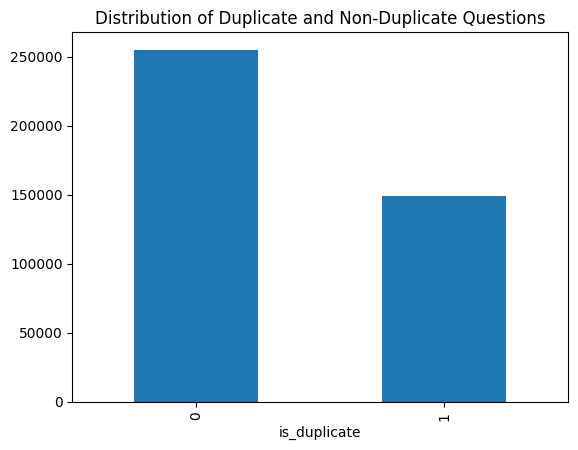

In [10]:
# Distribution of duplicate  and non-duplicate questions
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')
plt.title('Distribution of Duplicate and Non-Duplicate Questions')

Number of unique questions:  537933
Number of questions that appear more than once:  111780


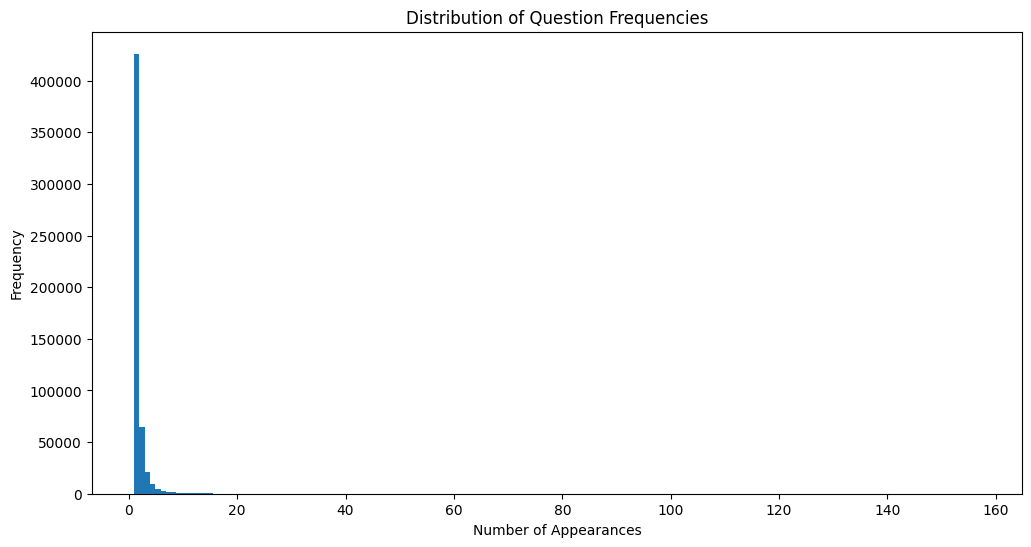

In [11]:
qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
plt.figure(figsize=(12, 6))
print("Number of unique questions: ", np.unique(qid).shape[0])
x = qid.value_counts()>1
print("Number of questions that appear more than once: ", x[x].shape[0])
plt.hist(qid.value_counts(), bins=160)
plt.xlabel('Number of Appearances')
plt.ylabel('Frequency')
plt.title('Distribution of Question Frequencies')
plt.show()

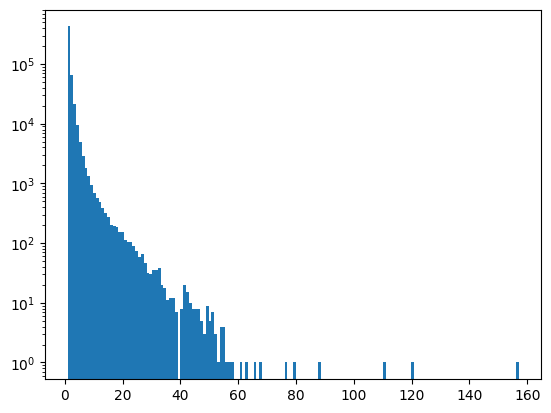

In [12]:
plt.hist(qid.value_counts(), bins=160)
plt.yscale("log")
plt.show()

# New Dataset 

In [13]:
new_df = df.sample(30000, random_state=2)

In [14]:
new_df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [15]:
new_df.shape

(30000, 6)

In [16]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


Text(0.5, 1.0, 'Distribution of Duplicate and Non-Duplicate Questions')

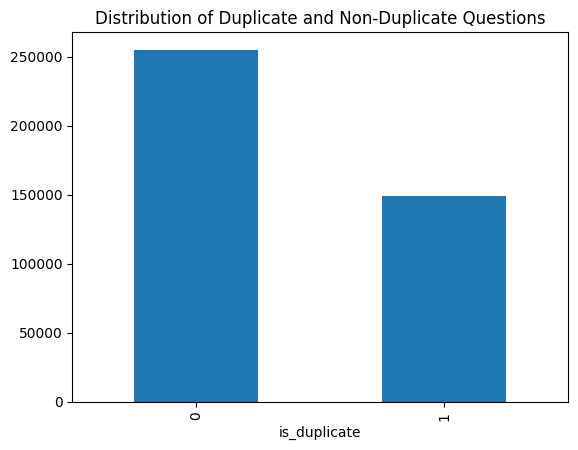

In [17]:
# Distribution of duplicate  and non-duplicate questions
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')
plt.title('Distribution of Duplicate and Non-Duplicate Questions')

Number of unique questions:  537933
Number of questions that appear more than once:  111780


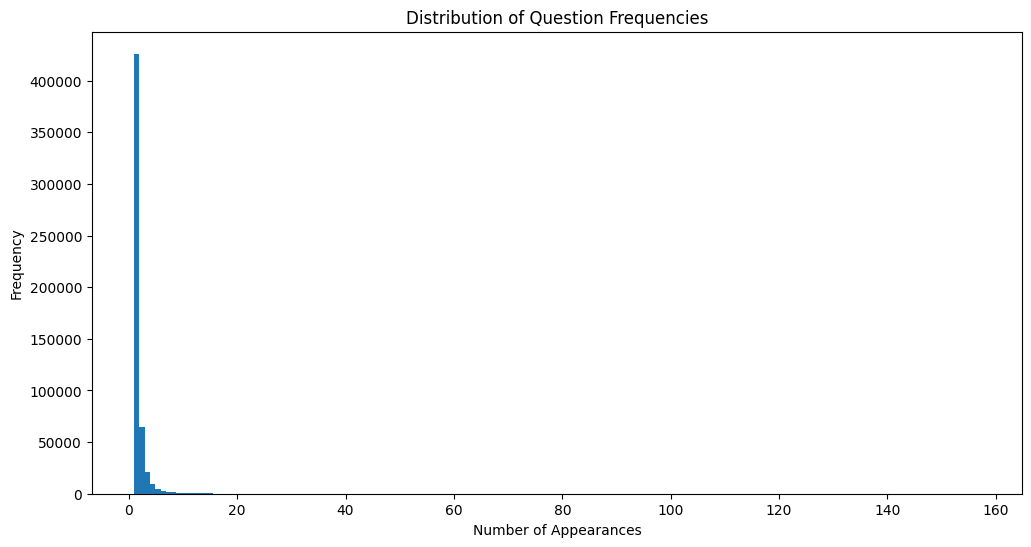

In [18]:
qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
plt.figure(figsize=(12, 6))
print("Number of unique questions: ", np.unique(qid).shape[0])
x = qid.value_counts()>1
print("Number of questions that appear more than once: ", x[x].shape[0])
plt.hist(qid.value_counts(), bins=160)
plt.xlabel('Number of Appearances')
plt.ylabel('Frequency')
plt.title('Distribution of Question Frequencies')
plt.show()

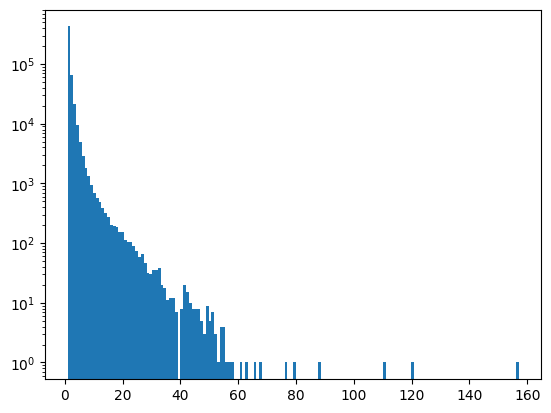

In [19]:
plt.hist(qid.value_counts(), bins=160)
plt.yscale("log")
plt.show()

In [20]:
new_df["q1_length"] = new_df["question1"].str.len()
new_df["q2_length"] = new_df["question2"].str.len()

In [21]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [22]:
new_df["q1_num_words"] = new_df["question1"].apply(lambda row: len(row.split(" ")))
new_df["q2_num_words"] = new_df["question2"].apply(lambda row: len(row.split(" ")))
new_df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [23]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [24]:
new_df["word_common"] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,word_common
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [25]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [26]:
new_df["word_total"] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,word_common,word_total
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [27]:
new_df["word_share"] = round(new_df["word_common"] / new_df["word_total"], 2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


# Analysis of features

Minimum length of question1:  2
Maximum length of question1:  391
Average length of question1:  59.7133


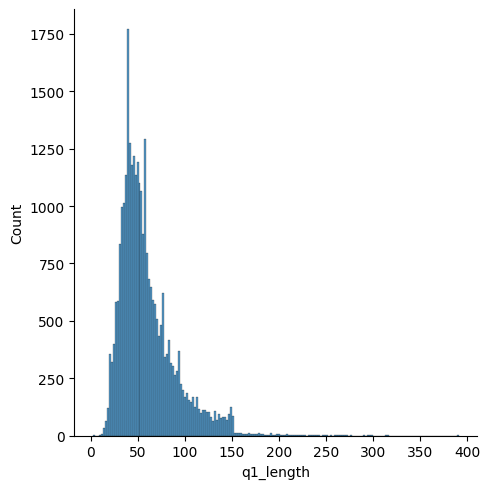

In [28]:
sns.displot(new_df['q1_length'])
print("Minimum length of question1: ", new_df['q1_length'].min())
print("Maximum length of question1: ", new_df['q1_length'].max ())
print("Average length of question1: ", new_df['q1_length'].mean())


Minimum length of question2:  6
Maximum length of question2:  1151
Average length of question2:  60.29343333333333


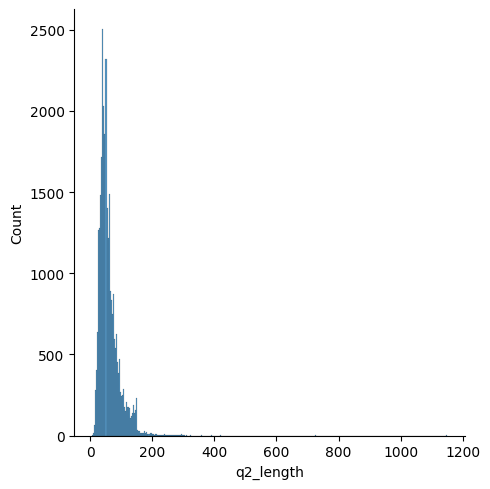

In [29]:
sns.displot(new_df['q2_length'])
print("Minimum length of question2: ", new_df['q2_length'].min())
print("Maximum length of question2: ", new_df['q2_length'].max ())
print("Average length of question2: ", new_df['q2_length'].mean())


Minimum number of words in question1:  1
Maximum number of words in question1:  72
Average number of words in question1:  10.969133333333334


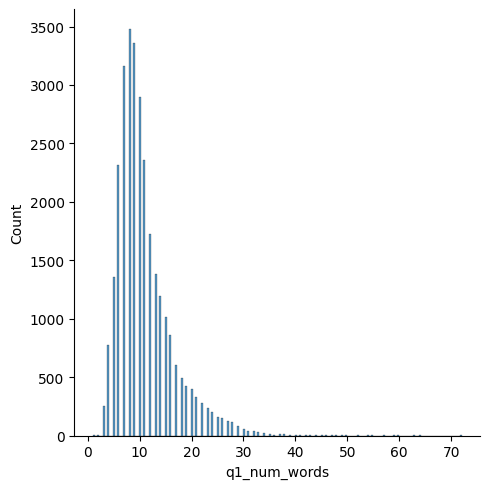

In [30]:
sns.displot(new_df['q1_num_words'])
print("Minimum number of words in question1: ", new_df['q1_num_words'].min())
print("Maximum number of words in question1: ", new_df['q1_num_words'].max())
print("Average number of words in question1: ", new_df['q1_num_words'].mean())


Minimum number of words in question2:  1
Maximum number of words in question2:  237
Average number of words in question2:  11.232133333333334


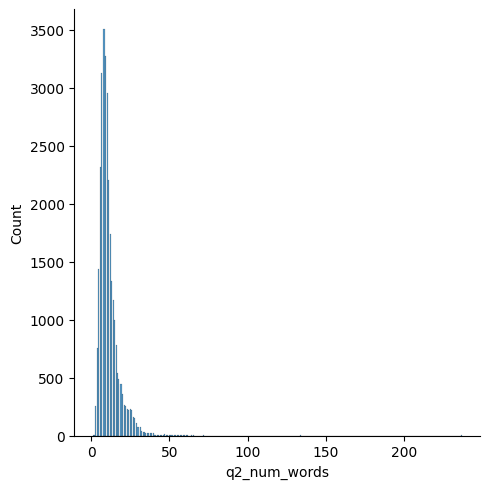

In [31]:
sns.displot(new_df['q2_num_words'])
print("Minimum number of words in question2: ", new_df['q2_num_words'].min())
print("Maximum number of words in question2: ", new_df['q2_num_words'].max())
print("Average number of words in question2: ", new_df['q2_num_words'].mean())


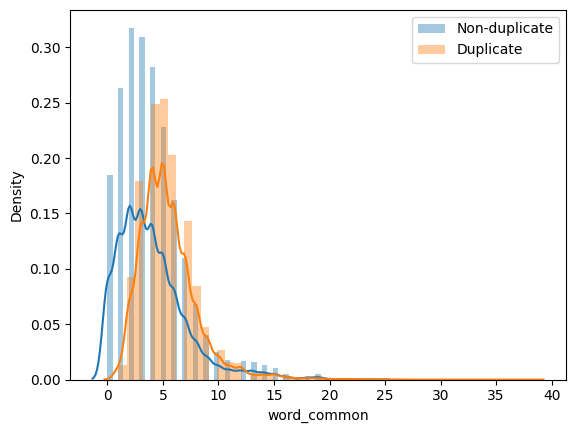

In [32]:
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0 ]['word_common'], label='Non-duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1 ]['word_common'], label='Duplicate')
plt.legend()
plt.show()

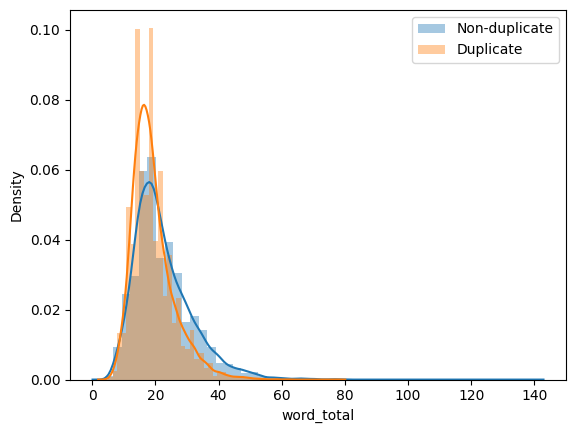

In [33]:
#total words
sns.distplot(new_df[new_df['is_duplicate'] == 0 ]['word_total'], label='Non-duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1 ]['word_total'], label='Duplicate')
plt.legend()
plt.show()

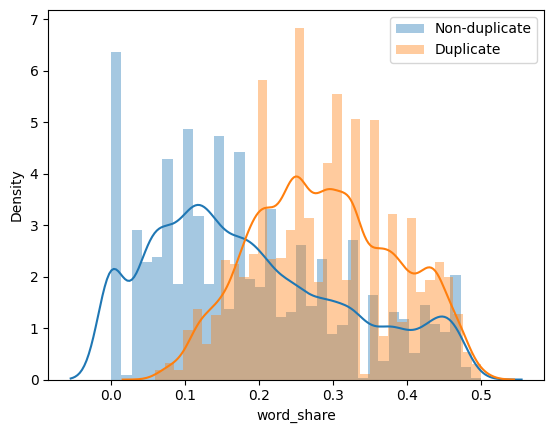

In [34]:
# word share
sns.distplot(new_df[new_df['is_duplicate'] == 0 ]['word_share'], label='Non-duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1 ]['word_share'], label='Duplicate')
plt.legend()
plt.show()

In [35]:
ques_df = new_df[['question1', 'question2']]
ques_df.head()

,question1,question2
398782,What is the best marketing automation tool for...,What is the best marketing automation tool for...
115086,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...
327711,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...
367788,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...
151235,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...


In [36]:
final_df = new_df.drop(columns=['id','qid1', 'qid2', 'question1', 'question2'])
print("Shape of final dataframe: ", final_df.shape)
final_df.head()

Shape of final dataframe:  (30000, 8)


,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,1,76,77,12,12,11,24,0.46
115086,0,49,57,12,15,7,23,0.30
327711,0,105,120,25,17,2,34,0.06
367788,0,59,146,12,30,0,32,0.00
151235,0,35,50,5,9,3,13,0.23


In [37]:
from sklearn.feature_extraction.text import CountVectorizer 
# merge texts 
question = list(ques_df['question1']) + list(ques_df['question2'])
cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(question).toarray(), 2)

In [38]:
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
print("Shape of temp dataframe: ", temp_df.shape)
temp_df.head()

Shape of temp dataframe:  (30000, 6000)


,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
final_df = pd.concat([final_df, temp_df], axis=1)
print("Shape of final dataframe: ", final_df.shape)
final_df.head()

Shape of final dataframe:  (30000, 6008)


,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,24,0.46,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,23,0.30,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,34,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.00,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(final_df.iloc[:,1: ].values, final_df.iloc[:,0].values , test_size=0.2, random_state=42)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
rf = RandomForestClassifier(n_estimators=100, random_state=2)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7633333333333333

In [42]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=2)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test, y_pred)


0.7668333333333334